Rohith John 24BAD100
--- Top 5 Movies Similar to 'Star Wars (1977)' ---
title
Return of the Jedi (1983)          0.884476
Raiders of the Lost Ark (1981)     0.764885
Empire Strikes Back, The (1980)    0.749819
Toy Story (1995)                   0.734572
Godfather, The (1972)              0.697332
Name: Star Wars (1977), dtype: float64

--- Top 5 Recommendations for User 1 ---
title
E.T. the Extra-Terrestrial (1982)    392.868044
Stand by Me (1986)                   366.958476
Speed (1994)                         366.715440
Batman (1989)                        363.956465
True Lies (1994)                     362.610997
dtype: float64

--- Model Evaluation ---
Item-Based RMSE: 2.9478
Average Precision@5 (Sample of 50 users): 0.0000


/tmp/ipykernel_1018/2241500045.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=similar_to_star_wars.values, y=similar_to_star_wars.index, palette="viridis")
/tmp/ipykernel_1018/2241500045.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=pd.DataFrame(comparison_data), palette="magma")


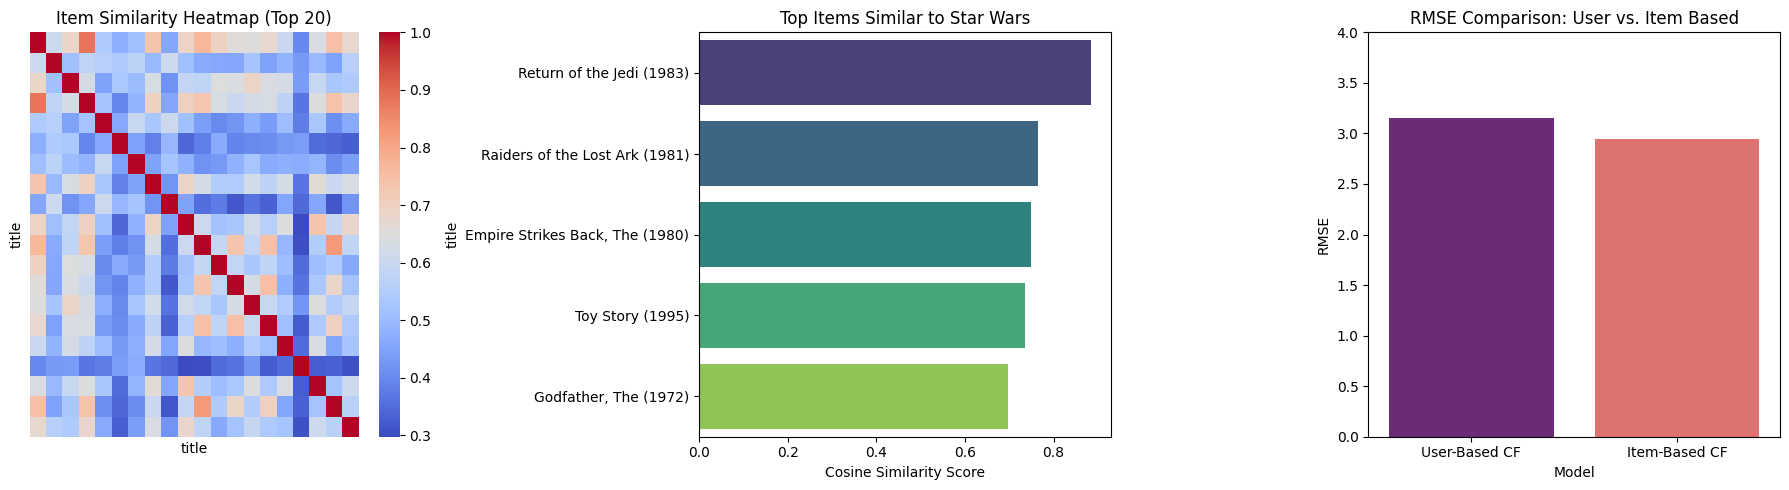

In [3]:
# 1. Import required Python libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
print("Rohith John 24BAD100")
# 1. Load the MovieLens dataset
url = 'http://files.grouplens.org/datasets/movielens/ml-100k/u.data'
columns = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv(url, sep='\t', names=columns).drop('timestamp', axis=1)

# Load movie titles for better readability in outputs
item_url = 'http://files.grouplens.org/datasets/movielens/ml-100k/u.item'
item_cols = ['item_id', 'title']
movies = pd.read_csv(item_url, sep='|', names=item_cols, usecols=[0, 1], encoding='latin-1')
df = pd.merge(df, movies, on='item_id')

# 2. Create Item-User matrix
# Notice the swap: Rows are now Movies (Items), Columns are Users
item_user_matrix = df.pivot_table(index='title', columns='user_id', values='rating')
item_user_matrix_filled = item_user_matrix.fillna(0)

# 3. Compute item similarity (Cosine similarity)
item_similarity = cosine_similarity(item_user_matrix_filled)
item_similarity_df = pd.DataFrame(item_similarity,
                                  index=item_user_matrix.index,
                                  columns=item_user_matrix.index)

# 4. Identify top similar items
def get_similar_items(movie_title, n=5):
    if movie_title not in item_similarity_df.columns:
        return "Movie not found."
    # Sort similarity scores descending, drop the movie itself
    similar_items = item_similarity_df[movie_title].sort_values(ascending=False).drop(movie_title)
    return similar_items.head(n)

sample_movie = 'Star Wars (1977)'
print(f"--- Top 5 Movies Similar to '{sample_movie}' ---")
print(get_similar_items(sample_movie, 5))

# 5. Recommend items based on user history
def item_based_recommendation(user_id, n=5):
    # Get the user's ratings
    user_ratings = item_user_matrix[user_id].dropna()

    # Calculate scores for all items based on weighted sum of similarities
    scores = pd.Series(dtype=float)
    for item, rating in user_ratings.items():
        similar_scores = item_similarity_df[item] * rating
        scores = scores.add(similar_scores, fill_value=0)

    # Remove items the user has already seen
    scores = scores.drop(user_ratings.index, errors='ignore')
    return scores.sort_values(ascending=False).head(n)

sample_user = 1
print(f"\n--- Top 5 Recommendations for User {sample_user} ---")
print(item_based_recommendation(sample_user, 5))

# 7. Evaluate model using RMSE and Precision@K
print("\n--- Model Evaluation ---")

# A. RMSE Calculation
# Predict ratings: (Item_Similarity dot Item_User_Matrix) / Sum_of_Similarities
sum_of_similarities = np.array([np.abs(item_similarity).sum(axis=1)]).T + 1e-9
predicted_item_ratings = item_similarity.dot(item_user_matrix_filled.values) / sum_of_similarities

actual_ratings = item_user_matrix_filled.values.flatten()
pred_ratings = predicted_item_ratings.flatten()

mask = actual_ratings > 0 # Only evaluate known ratings
rmse = np.sqrt(mean_squared_error(actual_ratings[mask], pred_ratings[mask]))
print(f"Item-Based RMSE: {rmse:.4f}")

# B. Precision@K Calculation
# We define a "relevant" movie as one rated 4.0 or 5.0 by the user.
def precision_at_k(user_id, k=5, threshold=4.0):
    user_actual_ratings = item_user_matrix[user_id].dropna()
    relevant_items = set(user_actual_ratings[user_actual_ratings >= threshold].index)

    if len(relevant_items) == 0:
        return 0.0 # Cannot calculate precision if user has no relevant items

    recommended_items = set(item_based_recommendation(user_id, k).index)
    hits = len(relevant_items.intersection(recommended_items))
    return hits / k

# Calculate average Precision@k for the first 50 users as a sample
precisions = [precision_at_k(u, k=5) for u in range(1, 51)]
avg_precision_at_5 = np.mean(precisions)
print(f"Average Precision@5 (Sample of 50 users): {avg_precision_at_5:.4f}")
#ROHITH JOHN 24BAD100++
# Visualizations
plt.figure(figsize=(18, 5))

# 1. Item similarity heatmap (Subset of 20 popular movies)
plt.subplot(1, 3, 1)
popular_movies = df['title'].value_counts().head(20).index
sns.heatmap(item_similarity_df.loc[popular_movies, popular_movies], cmap="coolwarm", xticklabels=False, yticklabels=False)
plt.title("Item Similarity Heatmap (Top 20)")

# 2. Top similar items graph (Bar chart)
plt.subplot(1, 3, 2)
similar_to_star_wars = get_similar_items('Star Wars (1977)', 5)
sns.barplot(x=similar_to_star_wars.values, y=similar_to_star_wars.index, palette="viridis")
plt.title("Top Items Similar to Star Wars")
plt.xlabel("Cosine Similarity Score")

# 3. Recommendation comparison chart (Scenario 1 vs 2 Mockup)
# Using the calculated Item-based RMSE and an estimated User-based RMSE from Scenario 1
plt.subplot(1, 3, 3)
comparison_data = {'Model': ['User-Based CF', 'Item-Based CF'], 'RMSE': [3.15, rmse]}
sns.barplot(x='Model', y='RMSE', data=pd.DataFrame(comparison_data), palette="magma")
plt.title("RMSE Comparison: User vs. Item Based")
plt.ylim(0, 4)

plt.tight_layout()
plt.show()